In [1]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [5]:
from sklearn.metrics import confusion_matrix

In [11]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
# Load dataset
iris_raw = load_iris()
X_iris = iris_raw.data
y_iris = iris_raw.target

# Standardize features
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# Stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_iris_scaled, y_iris, test_size=0.20, stratify=y_iris, random_state=42
)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize multinomial Logistic Regression classifier
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test data
lr_preds = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

In [15]:
cm = confusion_matrix(y_test, lr_preds)

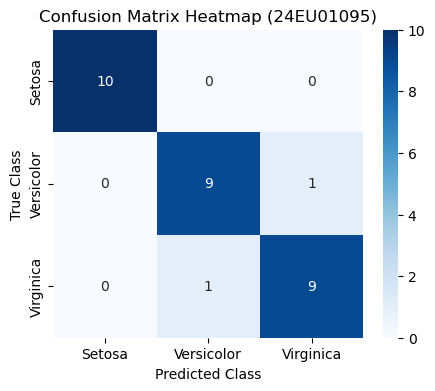

In [37]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.title("Confusion Matrix Heatmap (24EU01095)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [21]:
from sklearn.metrics import classification_report

In [23]:
report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

In [25]:
print("--- Logistic Regression Classification Report ---")
print(report_output)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [27]:
from sklearn.preprocessing import label_binarize

In [29]:
from sklearn.metrics import roc_curve, auc

In [31]:
import matplotlib.pyplot as plt

In [33]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

In [35]:
y_score = lr_model.predict_proba(X_test)

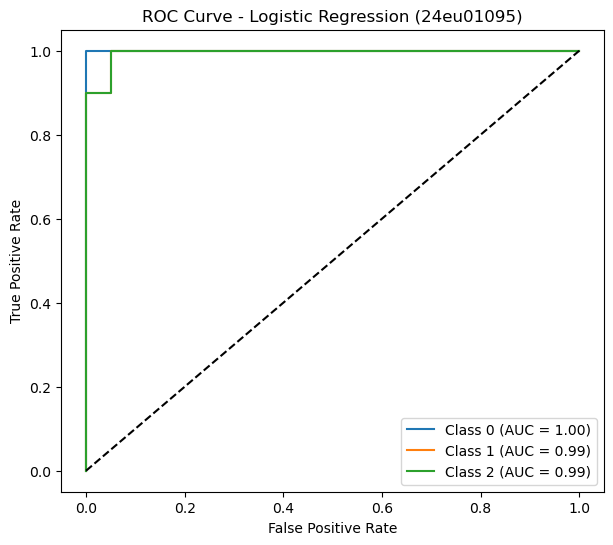

In [39]:
plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (24eu01095)")
plt.legend(loc="lower right")
plt.show()

In [41]:
from sklearn.datasets import load_iris

In [43]:
from sklearn.preprocessing import StandardScaler

In [45]:
from sklearn.linear_model import LogisticRegression

In [47]:
from sklearn.model_selection import cross_val_score

In [49]:
import numpy as np

In [51]:
iris = load_iris()

In [53]:
X = iris.data

In [55]:
y = iris.target

In [57]:
scaler = StandardScaler()

In [59]:
X_scaled = scaler.fit_transform(X)

In [61]:
lr_model = LogisticRegression(max_iter=200)

In [63]:
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

In [65]:
print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

5-Fold Cross-Validation Accuracy:
Fold 1: 0.9667
Fold 2: 1.0000
Fold 3: 0.9333
Fold 4: 0.9000
Fold 5: 1.0000

Mean Accuracy: 96.00%
Standard Deviation: 3.89%
